<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/main/Jason_Lim_hw_3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/cursor/hw-3-sentiment-topic-a051/Jason_Lim_hw_3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 3a — LLM Fundamentals (UCSC Extension)
# Homework 3a: Sentiment Analysis with VADER

Jason Lim  

## Goal
Apply **VADER** (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis to **unstructured free-text product reviews**, then compare VADER predictions against the dataset’s ground-truth labels.

## Dataset
**UCI Sentiment Labelled Sentences — Amazon cell phone / product reviews**  
https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences

- 1,000 Amazon product review sentences
- Label `1` = positive, `0` = negative
- Short, clearly polar review sentences (good homework-sized unstructured text)

## References
- Class VADER notebook: Valence Aware Dictionary and sEntiment Reasoner
- Class 3a / Hands-On LLM Ch. 4 themes: text classification + evaluation with `classification_report`


## Step 0 — Install + imports

In [1]:
%%capture
!pip install -q vaderSentiment pandas matplotlib seaborn scikit-learn


In [2]:
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style="whitegrid")
%matplotlib inline


## Step 1 — Load Amazon product reviews (UCI)

Format of each line: `sentence <TAB> score` where score is 0 (negative) or 1 (positive).


In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip"

with urlopen(DATA_URL) as resp:
    zf = ZipFile(BytesIO(resp.read()))

# Product reviews: Amazon cell-phone accessories / electronics sentences
with zf.open("sentiment labelled sentences/amazon_cells_labelled.txt") as f:
    df = pd.read_csv(f, sep="\t", header=None, names=["text", "label"])

print("Shape:", df.shape)
print("Label counts:\n", df["label"].value_counts().sort_index())
df.head(10)


Shape: (1000, 2)
Label counts:
 label
0    500
1    500
Name: count, dtype: int64


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
5,I have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,1
8,"Needless to say, I wasted my money.",0
9,What a waste of money and time!.,0


## Step 2 — Quick look at positive vs negative reviews

Unstructured free-text examples from the product review corpus.


In [4]:
print("=== Positive examples (label=1) ===")
for t in df.loc[df["label"] == 1, "text"].head(5):
    print("-", t)

print("\n=== Negative examples (label=0) ===")
for t in df.loc[df["label"] == 0, "text"].head(5):
    print("-", t)


=== Positive examples (label=1) ===
- Good case, Excellent value.
- Great for the jawbone.
- The mic is great.
- If you are Razr owner...you must have this!
- And the sound quality is great.

=== Negative examples (label=0) ===
- So there is no way for me to plug it in here in the US unless I go by a converter.
- Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!
- I have to jiggle the plug to get it to line up right to get decent volume.
- If you have several dozen or several hundred contacts, then imagine the fun of sending each of them one by one.
- Needless to say, I wasted my money.


## Step 3 — VADER warm-up (same idea as the class VADER notebook)

VADER returns `neg`, `neu`, `pos`, and a **compound** score in `[-1, 1]`.
The compound score is the main overall tone signal.


In [5]:
analyzer = SentimentIntensityAnalyzer()

angry_review = "The food was disgusting. I am never coming back here again!!"
great_review = "This phone case is excellent value. I am going to buy another one!!!"

print("Angry review scores:", analyzer.polarity_scores(angry_review))
print("Great review scores:", analyzer.polarity_scores(great_review))


Angry review scores: {'neg': 0.285, 'neu': 0.715, 'pos': 0.0, 'compound': -0.6103}
Great review scores: {'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.7891}


In [6]:
def classify_text(text, threshold=0.0):
    """Classify text with VADER using the compound score.

    threshold=0 follows the class VADER notebook:
      compound >= threshold → positive (1)
      compound <  threshold → negative (0)
    """
    scores = analyzer.polarity_scores(text)
    compound = scores["compound"]
    pred_class = 1 if compound >= threshold else 0
    return pred_class, compound, scores


for example in [
    great_review,
    "the food was really bad",
    "what is your name",
    "Great battery life but the mic is awful.",
]:
    pred, compound, scores = classify_text(example)
    print(f"pred={pred}  compound={compound:+.3f}  |  {example}")
    print(" ", scores)


pred=1  compound=+0.789  |  This phone case is excellent value. I am going to buy another one!!!
  {'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.7891}
pred=0  compound=-0.585  |  the food was really bad
  {'neg': 0.487, 'neu': 0.513, 'pos': 0.0, 'compound': -0.5849}
pred=1  compound=+0.000  |  what is your name
  {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
pred=0  compound=-0.351  |  Great battery life but the mic is awful.
  {'neg': 0.319, 'neu': 0.478, 'pos': 0.203, 'compound': -0.3506}


## Step 4 — Run VADER on all Amazon product reviews

Store compound / pos / neu / neg scores and a binary prediction.


In [7]:
rows = []
for text in df["text"]:
    pred, compound, scores = classify_text(text, threshold=0.0)
    rows.append(
        {
            "pred": pred,
            "compound": compound,
            "vader_pos": scores["pos"],
            "vader_neu": scores["neu"],
            "vader_neg": scores["neg"],
        }
    )

scored = pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
scored["correct"] = scored["pred"] == scored["label"]
scored.head(10)


,text,label,pred,compound,vader_pos,vader_neu,vader_neg,correct
0,So there is no way for me to plug it in here i...,0,0,-0.3535,0.000,0.890,0.110,True
1,"Good case, Excellent value.",1,1,0.8402,0.900,0.100,0.000,True
2,Great for the jawbone.,1,1,0.6249,0.577,0.423,0.000,True
3,Tied to charger for conversations lasting more...,0,0,-0.6145,0.000,0.713,0.287,True
4,The mic is great.,1,1,0.6249,0.577,0.423,0.000,True
5,I have to jiggle the plug to get it to line up...,0,1,0.0000,0.000,1.000,0.000,False
6,If you have several dozen or several hundred c...,0,1,0.5106,0.142,0.858,0.000,False
7,If you are Razr owner...you must have this!,1,1,0.0000,0.000,1.000,0.000,True
8,"Needless to say, I wasted my money.",0,0,-0.4939,0.000,0.652,0.348,True
9,What a waste of money and time!.,0,0,-0.4753,0.000,0.660,0.340,True


## Step 5 — Evaluate against ground-truth labels

Accuracy: 0.768

                 precision    recall  f1-score   support

Negative Review       0.97      0.55      0.70       500
Positive Review       0.69      0.98      0.81       500

       accuracy                           0.77      1000
      macro avg       0.83      0.77      0.76      1000
   weighted avg       0.83      0.77      0.76      1000



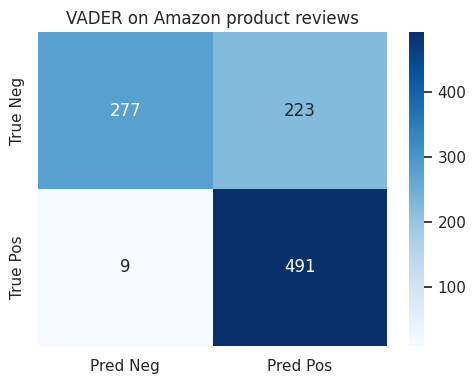

In [8]:
y_true = scored["label"]
y_pred = scored["pred"]

print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print()
print(
    classification_report(
        y_true, y_pred, target_names=["Negative Review", "Positive Review"]
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Neg", "Pred Pos"],
    yticklabels=["True Neg", "True Pos"],
    ax=ax,
)
ax.set_title("VADER on Amazon product reviews")
plt.tight_layout()
plt.show()


## Step 6 — Visualize the compound-score distribution

Near-zero compound scores are more neutral / mixed. Strong positives and negatives sit near ±1.


/tmp/ipykernel_573/1878165470.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_573/1878165470.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Negative", "Positive"])


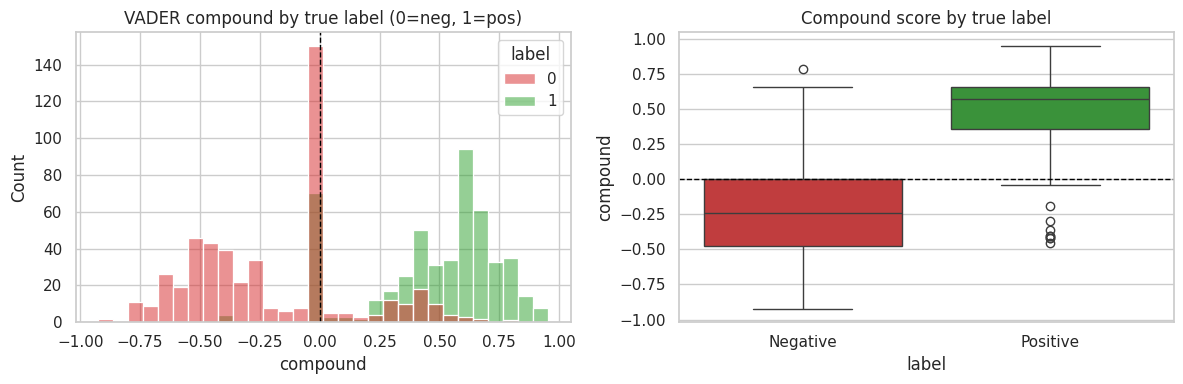

Mean compound by true label:
label
0   -0.192667
1    0.481739
Name: compound, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=scored,
    x="compound",
    hue="label",
    bins=30,
    ax=axes[0],
    palette=["#d62728", "#2ca02c"],
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("VADER compound by true label (0=neg, 1=pos)")

sns.boxplot(
    data=scored,
    x="label",
    y="compound",
    ax=axes[1],
    palette=["#d62728", "#2ca02c"],
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Compound score by true label")
axes[1].set_xticklabels(["Negative", "Positive"])

plt.tight_layout()
plt.show()

print("Mean compound by true label:")
print(scored.groupby("label")["compound"].mean())


## Step 7 — Error analysis

Look at a few misclassified reviews. These often contain mixed sentiment, sarcasm, or domain words VADER underweights.


In [10]:
errors = scored.loc[~scored["correct"]].copy()
print(f"Misclassified: {len(errors)} / {len(scored)} ({100 * len(errors) / len(scored):.1f}%)\n")

print("=== False negatives (true=1, pred=0): positive reviews VADER called negative ===")
fn = errors[errors["label"] == 1].sort_values("compound").head(8)
for _, r in fn.iterrows():
    print(f"compound={r['compound']:+.3f} | {r['text']}")

print("\n=== False positives (true=0, pred=1): negative reviews VADER called positive ===")
fp = errors[errors["label"] == 0].sort_values("compound", ascending=False).head(8)
for _, r in fp.iterrows():
    print(f"compound={r['compound']:+.3f} | {r['text']}")


Misclassified: 232 / 1000 (23.2%)

=== False negatives (true=1, pred=0): positive reviews VADER called negative ===
compound=-0.457 | great...no problems at all!.
compound=-0.417 | I was looking for this headset for a long time and now that I've got it I couldn't be happier.
compound=-0.417 | I am pairing this with my iphone, and I could not be happier with it so far.
compound=-0.404 | No shifting, no bubbling, no peeling, not even a scratch, NOTHING!I couldn't be more happier with my new one for the Droid.
compound=-0.402 | This fixes all the problems.
compound=-0.361 | Works great, when my cat attacked the phone he scratched the protective strip instead of destroying the screen.
compound=-0.296 | The range is very decent, I've been able to roam around my house with the phone in the living room with no reception/sound quality issues.
compound=-0.188 | It plays louder than any other speaker of this size; the price is so low that most would think the quality is lacking, however, it's no

## Step 8 — Optional threshold experiment

The class notebook used `threshold=0`. Trying a small dead-zone around 0 can treat near-neutral reviews as a separate bucket for business filtering (as noted in the VADER lab).


In [12]:
def ternary_label(compound, pos_thresh=0.05, neg_thresh=-0.05):
    if compound >= pos_thresh:
        return "positive"
    if compound <= neg_thresh:
        return "negative"
    return "neutral / mixed"

scored["vader_ternary"] = scored["compound"].apply(ternary_label)
print(scored["vader_ternary"].value_counts())
print()

# Among clearly polar VADER predictions, check agreement with ground truth
polar = scored[scored["vader_ternary"] != "neutral / mixed"].copy()
polar_pred = (polar["vader_ternary"] == "positive").astype(int)
print(
    "Accuracy on non-neutral VADER calls only:",
    round(accuracy_score(polar["label"], polar_pred), 4),
)
print("Count used:", len(polar), "/", len(scored))


vader_ternary
positive           497
negative           280
neutral / mixed    223
Name: count, dtype: int64

Accuracy on non-neutral VADER calls only: 0.8919
Count used: 777 / 1000


## Learnings / analysis notes

1. **Dataset choice:** Amazon cell-product review sentences are short, unstructured free text with clear polarity — a good fit for VADER homework.
2. **VADER compound score:** Combines lexicon valence with punctuation / capitalization / intensifiers. `>= 0` → positive class in the class notebook convention.
3. **Evaluation:** Comparing against UCI labels with `classification_report` + confusion matrix connects the VADER lab to Class 3a text-classification evaluation practice.
4. **Errors:** Mixed reviews (“great battery but awful mic”) and domain jargon can confuse lexicon methods. Near-zero compound scores are useful to filter out low-signal text before business analytics.